In [1]:
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

c:\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm = init_chat_model("gemini-2.5-flash", model_provider="google_genai")

In [3]:
# Create Tools
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

In [4]:
# Create LLM that can call tools 
tools = [add, multiply]
llm_with_tools = llm.bind_tools(tools)

In [5]:
sys_msg = SystemMessage(content="Either use tools to perform arithmetic on a set of inputs or just give me answer with your knowledge")
# Node to call LLM
def tool_calling_llm(state: MessagesState) -> MessagesState:
   ai_messages = llm_with_tools.invoke([sys_msg] + state["messages"])
   return {"messages": [ai_messages]}  # adds this message to existing messages 



In [6]:
tool_node =  ToolNode(tools)

In [14]:
# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", tool_node)   # Node to call tools


In [ ]:
# Define edges: these determine how the control flow moves
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")
react_graph = builder.compile()

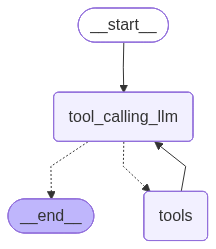

In [16]:
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [ ]:
human_messages = [HumanMessage(content="Add 343433 and 4232323 then multiply the result by 10")]
response = react_graph.invoke({"messages": human_messages})

In [ ]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 343433 and 4232323 then multiply the result by 10
================================== Ai Message ==================================
Tool Calls:
  add (1e1cbb62-0fae-44ee-89a0-335269da6351)
 Call ID: 1e1cbb62-0fae-44ee-89a0-335269da6351
  Args:
    a: 343433
    b: 4232323
================================= Tool Message =================================
Name: add

4575756
================================== Ai Message ==================================
Tool Calls:
  multiply (40395a66-55c7-407b-a57e-08e217958f37)
 Call ID: 40395a66-55c7-407b-a57e-08e217958f37
  Args:
    a: 4575756
    b: 10
================================= Tool Message =================================
Name: multiply

45757560
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The answer is 45757560.', 'extras': {'signature': 'CtMBAb4+9vv5FS2y2b3UxgknLuDzfEw/LhsCfFRFKCmO0+h5JA+ap

In [ ]:
messages = [HumanMessage(content="What is the capital of Spain?")]
response = react_graph.invoke({"messages": messages})


for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the capital of Spain?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The capital of Spain is Madrid.', 'extras': {'signature': 'CucDAb4+9vv3ShiaoIANx4VMsIhYk9bfdGqKcTsbLDND0WTDcbmZ7c+jISCl2jGvkRAw7pkgq+Y9/duqApHhepeTJ7A0O8xZnyJw0uoH3BQqpig5BxXhEYN/5WrfMpkpZqTLtw+6ruBrXmFpkro02rIhvN/GXkZYFB3ATSJ0tzksx+9pzjKQjmxQcGXsH8Gu6LGQcQqdq63XJ0/IFmsCPFsqsZm9SSRZtos5i65/y3Pm3Z2mzMFCAg5UXpPm5BF6B6du8Qt/bhZDkIlJdltc9lfKenCXOqSXsiC7tIFTD2sbL0hSF3m/ks7qc8TxwwfJaWrywep/X+tFplS4Qh2onhWG75vvcTCW7Z5vOah76ZkJRS0eS1Yt1EJXs4vQZEP1WB1ZKqxk+Qh/+6l4qzjydUgDHwAeyNE0ZdMALNyDjB/xkeSA3Be5Criuwz2Q58iy3InRgyT/EKcGkZ0gKore710K1F8DuAomMct1iI6KfLCuA5q/6vv/c6rP3sqqvUpOVAR2KGU44wQDaJIRb+I6gnF8srJbITkkGeTxaGy4MoQSxg+stISpWIdzRU/DBgL7jfGf/C2Nri3l3fcG7kRxDMugv4uBS2GZRH96INata+qH4zZ1Vti5tyOwdT00WZwqjCuXYKpo8gkkxA=='}}]
